# Benchmark CH4 Klasik -- Full Range (0.20-5.80 A)
### Perbandingan Kurva Energi Potensial (PES) C-H pada CH4
**Metode:** HF, B3LYP, CASSCF(4,4), CASCI approx. (maxiter=1), FCI(10,9) -- basis STO-3G

---
**Catatan metodologi:**
- Data merupakan **gabungan 2 range** Rigid Scan (Single Point/SP):
  - **Range 1:** R = 0.20-3.00 A, 16 titik uniform
  - **Range 2:** R = 3.00-5.80 A, 16 titik uniform
  - Titik R=3.00 A hanya diambil dari Range 1 (tidak duplikasi), mengikuti konvensi yang sama dengan gabungan H2O.

**Catatan penting (CASSCF -- SUDAH DIVALIDASI KONSISTEN):**
- Awalnya Range 1 memakai `switchstep nr` sedangkan Range 2 tidak, menyebabkan selisih energi CASSCF sebesar ~1.76 Ha di titik sambung R=3.00 A (bukan noise numerik).
- Setelah Range 2 di-rerun dengan `switchstep nr` ditambahkan (menyamakan strategi optimasi orbital dengan Range 1), selisih di titik sambung R=3.00 A turun menjadi **0.0317 mHa** -- jauh di bawah chemical accuracy (1.6 mHa). CASSCF Range 1 dan Range 2 sekarang **konsisten dan valid digabung**.

**Catatan penting (CASCI -- keterbatasan diketahui, belum sepenuhnya konsisten):**
- `E_CASCI` dihitung dengan `maxiter=1` (tanpa optimasi orbital, bukan CASCI variasional sejati), tanpa langkah HF terpisah.
- Karena `maxiter=1` tidak mengoptimasi orbital sama sekali, hasilnya **sangat bergantung pada orbital awal (initial guess)** di tiap titik scan.
- Pada scan ORCA berurutan (`%paras`), titik berikutnya biasa mewarisi orbital dari titik sebelumnya (warm start). Karena Range 1 dan Range 2 adalah **dua job scan terpisah**, orbital awal di R=3.00 (titik terakhir Range 1, hasil evolusi bertahap) berbeda dengan orbital awal Range 2 (titik pertama, fresh start).
- Akibatnya, walau setting `%casscf` identik di kedua range (sama-sama tanpa `switchstep nr`, karena `maxiter=1` membuat `switchstep` tidak relevan), kurva CASCI **masih menunjukkan patahan kecil** tepat setelah R=3.00 A.
- **Ini justru mendukung argumen ilmiah:** CASSCF (variational, teroptimasi penuh) bersifat *path-independent*, sedangkan CASCI naif (`maxiter=1`) bersifat *path-dependent*. Ini salah satu alasan kenapa CASCI 1-iterasi bukan pendekatan yang andal dibanding CASSCF penuh.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Hasil Simulasi (ORCA, Rigid Scan / SP)

In [2]:
import numpy as np

# ===========================================================
# RANGE 1: R = 0.20-3.00 A, 16 titik
# ===========================================================
R1 = list(np.linspace(0.20, 3.00, 16))

E_HF1 = [-32.274253992532, -37.547027539854, -38.973979098111, -39.451370324297,
        -39.598680684664, -39.622047226953, -39.597260540615, -39.554516787543,
        -39.507067346670, -39.460984240319, -39.419113712808, -39.382649855616,
        -39.351791025298, -39.326178287104, -39.305217222259, -39.288258175802]

E_DFT1 = [-32.578275917379, -37.843229465617, -39.262710503488, -39.736915930964,
         -39.884235324031, -39.911551739819, -39.894517600785, -39.862439463612,
         -39.827305176718, -39.793976941310, -39.764409938070, -39.739272908129,
         -39.718525201181, -39.701761286658, -39.688451304067, -39.678060018461]

E_CASCI1 = [-32.234766303777, -37.474918791153, -38.787257316965, -39.119605569238,
           -39.115209880928, -38.995623840969, -38.846860101448, -38.703021096530,
           -38.576488993539, -38.470115059686, -38.383081370327, -38.313313991501,
           -38.258298959742, -38.215464100962, -38.182436360616, -38.157163790342]

E_CASSCF1 = [-32.309633035040, -37.584619837838, -39.012102776001, -39.489148325511,
            -39.635912125186, -39.658754235864, -39.633487032229, -39.590282926075,
            -39.542382102742, -39.578211189570, -39.566078527362, -39.559075676493,
            -39.555311313002, -39.553363704691, -39.552375800278, -39.551882422566]

E_FCI1 = [-32.341479334104, -37.615096703845, -39.046151548313, -39.527765687953,
         -39.680405832615, -39.711423005300, -39.697877588839, -39.671176487561,
         -39.645164239611, -39.625224586327, -39.612123283199, -39.604416272114,
         -39.600197770068, -39.597981259014, -39.596843553042, -39.596270730145]

# ===========================================================
# RANGE 2: R = 3.00-5.80 A, 16 titik
# ===========================================================
R2 = list(np.linspace(3.00, 5.80, 16))

E_HF2 = [-39.288259310646, -39.274665112793, -39.263829464482, -39.255193542590,
        -39.248271746544, -39.242661000101, -39.238045459732, -39.234177989654,
        -39.230877095157, -39.228008809243, -39.225476606288, -39.223207621148,
        -39.221150189029, -39.219266188635, -39.217528011516, -39.215914482106]

E_DFT2 = [-39.678060017924, -39.670088477999, -39.664084670802, -39.659608573034,
         -39.656293331655, -39.653861268284, -39.652065315506, -39.650698999739,
         -39.649639147140, -39.648812002810, -39.648158215170, -39.647629011206,
         -39.647178349847, -39.646773802601, -39.646402653329, -39.646061342604]

# CASSCF Range 2 -- VERSI BARU, sudah pakai switchstep nr (konsisten dgn Range 1)
E_CASSCF2 = [-39.551914149360, -39.551655020831, -39.551531186964, -39.551473717228,
             -39.551447638708, -39.551436186564, -39.551431321791, -39.551429311733,
             -39.551428357232, -39.551428163216, -39.551427999610, -39.551427919941,
             -39.551427878850, -39.551427856449, -39.551427843664, -39.551427836245]

E_CASCI2 = [-39.120693367171, -39.111678539850, -39.103174393380, -39.095322072049,
           -39.088145943384, -39.081611514293, -39.075659898168, -39.070226479430,
           -39.065249810572, -39.060675050996, -39.056454686741, -39.052548063490,
           -39.048920510543, -39.045542409649, -39.042388344971, -39.039436379085]

E_FCI2 = [-39.596270730819, -39.595988753261, -39.595853604291, -39.595790643725,
         -39.595762115794, -39.595749526441, -39.595744113381, -39.595741848976,
         -39.595740929762, -39.595740568706, -39.595740431796, -39.595740381405,
         -39.595740363433, -39.595740357078, -39.595740354888, -39.595740354118]

# ===========================================================
# GABUNGKAN (skip R=3.00 dari Range 2, sudah ada di Range 1)
# ===========================================================
R         = R1 + R2[1:]
E_HF      = E_HF1     + E_HF2[1:]
E_DFT     = E_DFT1    + E_DFT2[1:]
E_CASSCF  = E_CASSCF1 + E_CASSCF2[1:]
E_CASCI   = E_CASCI1  + E_CASCI2[1:]
E_FCI     = E_FCI1    + E_FCI2[1:]

print(f'Total titik R: {len(R)} ({R[0]:.2f} - {R[-1]:.2f} A)')


Total titik R: 31 (0.20 - 5.80 A)


## 2. Hitung Error Relatif

Referensi: **FCI(10,9)** -- energi eksak dalam basis set STO-3G.

In [3]:
# -- Referensi: FCI --
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)

CA = 0.0016  # Chemical Accuracy (Hartree)

idx_fci = E_FCI.index(min(E_FCI))

print(f'R_eq (FCI) = {R[idx_fci]:.2f} A | E = {E_FCI[idx_fci]:.6f} Ha')
print(f'Mean |dE| HF     vs FCI = {np.mean(error_hf):.6e} Ha')
print(f'Mean |dE| B3LYP  vs FCI = {np.mean(error_dft):.6e} Ha')
print(f'Mean |dE| CASSCF vs FCI = {np.mean(error_casscf):.6e} Ha')
print(f'Mean |dE| CASCI  vs FCI = {np.mean(error_casci):.6e} Ha')

# -- Cek besar patahan CASCI tepat di seam R=3.00 --
seam_jump_casci = abs(E_CASCI[15] - E_CASCI[16])
print(f'\nPatahan CASCI di seam (R={R[15]:.2f} ke R={R[16]:.2f}): {seam_jump_casci:.4f} Ha  <-- lihat catatan metodologi')


R_eq (FCI) = 1.13 A | E = -39.711423 Ha
Mean |dE| HF     vs FCI = 2.550801e-01 Ha
Mean |dE| B3LYP  vs FCI = 1.150594e-01 Ha
Mean |dE| CASSCF vs FCI = 4.715171e-02 Ha
Mean |dE| CASCI  vs FCI = 7.172740e-01 Ha

Patahan CASCI di seam (R=3.00 ke R=3.19): 0.9545 Ha  <-- lihat catatan metodologi


## 3. Plot Kurva Energi Potensial (PES) dan Error

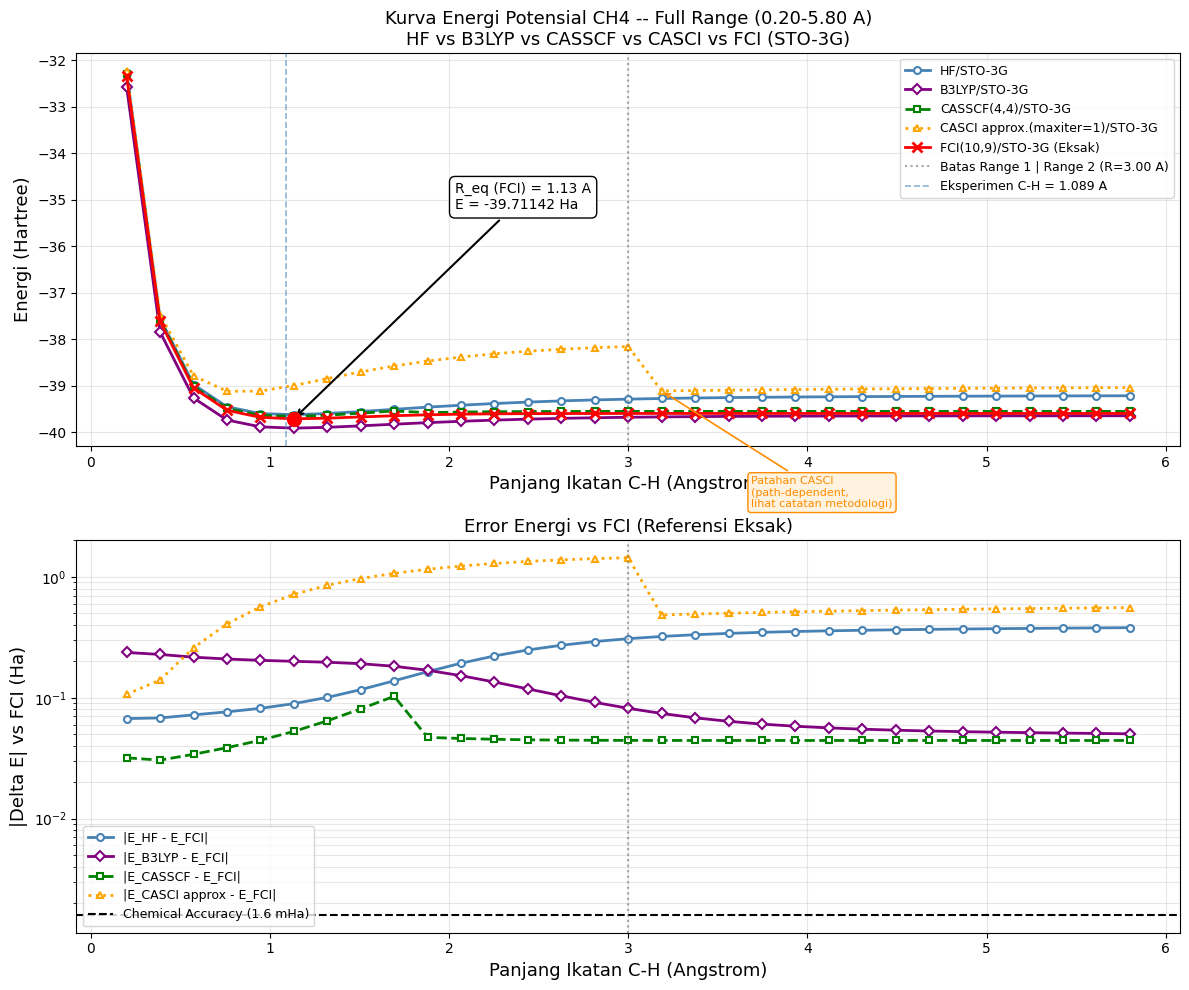

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# -- Plot 1: PES Full Range --
ax1.plot(R, E_HF,    'o-',  color='steelblue', linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,   'D-',  color='purple',    linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF,'s--', color='green',     linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='CASSCF(4,4)/STO-3G')
ax1.plot(R, E_CASCI, '^:',  color='orange',    linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='CASCI approx.(maxiter=1)/STO-3G')
ax1.plot(R, E_FCI,   'x-',  color='red',       linewidth=2,
         markersize=7, markeredgewidth=2,
         label='FCI(10,9)/STO-3G (Eksak)')

ax1.plot(R[idx_fci], E_FCI[idx_fci], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq (FCI) = {R[idx_fci]:.2f} A\nE = {E_FCI[idx_fci]:.5f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]+0.9, E_FCI[idx_fci]+4.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=3.00, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
            label='Batas Range 1 | Range 2 (R=3.00 A)')
ax1.axvline(x=1.089, color='steelblue', linestyle='--',
            linewidth=1.2, alpha=0.6, label='Eksperimen C-H = 1.089 A')

# -- Tandai patahan CASCI di seam (temuan path-dependency) --
ax1.annotate('Patahan CASCI\n(path-dependent,\nlihat catatan metodologi)',
             xy=(R[16], E_CASCI[16]),
             xytext=(R[16]+0.5, E_CASCI[16]-2.5),
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2),
             fontsize=8, color='darkorange',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0',
                       edgecolor='darkorange', linewidth=1))

ax1.set_xlabel('Panjang Ikatan C-H (Angstrom)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial CH4 -- Full Range (0.20-5.80 A)\n'
              'HF vs B3LYP vs CASSCF vs CASCI vs FCI (STO-3G)',
              fontsize=13)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# -- Plot 2: Error vs FCI --
ax2.semilogy(R, error_hf     + 1e-10, 'o-',  color='steelblue', linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_HF - E_FCI|')
ax2.semilogy(R, error_dft    + 1e-10, 'D-',  color='purple',    linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(R, error_casscf + 1e-10, 's--', color='green',     linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_CASSCF - E_FCI|')
ax2.semilogy(R, error_casci  + 1e-10, '^:',  color='orange',    linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_CASCI approx - E_FCI|')
ax2.axhline(y=CA, color='black', linestyle='--',
            linewidth=1.5, label='Chemical Accuracy (1.6 mHa)')
ax2.axvline(x=3.00, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Panjang Ikatan C-H (Angstrom)', fontsize=13)
ax2.set_ylabel('|Delta E| vs FCI (Ha)', fontsize=13)
ax2.set_title('Error Energi vs FCI (Referensi Eksak)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('PES_CH4_full_0.2to5.8.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Ringkasan Energi Elektronik

In [5]:
print('='*70)
print('RINGKASAN ENERGI ELEKTRONIK CH4 (STO-3G), Full Range 0.20-5.80 A')
print('='*70)
print(f'{"Metode":<22} {"E_min (Ha)":>15} {"R_eq (A)":>10} {"E(5.80 A)":>14}')
print('-'*70)
datasets = {
    'HF':            E_HF,
    'B3LYP':         E_DFT,
    'CASSCF(4,4)':   E_CASSCF,
    'CASCI approx.': E_CASCI,
    'FCI(10,9)':     E_FCI,
}
for nama, E in datasets.items():
    idx = E.index(min(E))
    print(f'{nama:<22} {E[idx]:>15.6f} {R[idx]:>10.2f} {E[-1]:>14.6f}')
print('='*70)


RINGKASAN ENERGI ELEKTRONIK CH4 (STO-3G), Full Range 0.20-5.80 A
Metode                      E_min (Ha)   R_eq (A)      E(5.80 A)
----------------------------------------------------------------------
HF                          -39.622047       1.13     -39.215914
B3LYP                       -39.911552       1.13     -39.646061
CASSCF(4,4)                 -39.658754       1.13     -39.551428
CASCI approx.               -39.119606       0.76     -39.039436
FCI(10,9)                   -39.711423       1.13     -39.595740
